# Kernel Visualization Demo

This notebook shows how to create an `ElongatedMaskKernel`
(with default and custom parameters), and how to plot it:

- **all orientations** in a grid (`plot_all` / `plot_kernel_grid`),
- **a single selected orientation** in a larger, more detailed view
  (`plot` / `plot_single_kernel`).


## 1. Imports

In [1]:
from image_processing import ElongatedMaskKernel, ElongatedMaskParams

print("image_processing imported.")

image_processing imported.


## 2. Creating a kernel with default parameters

If you don't pass `params`, `ElongatedMaskKernel` uses the default
values of `ElongatedMaskParams`
(`n_angles=10`, `kernel_half_size=20`, ...).
We pass `device="cpu"` so the notebook runs deterministically
even without a GPU.


In [2]:
kernel = ElongatedMaskKernel(device="cpu")

print(f"Number of orientations : {kernel.params.n_angles}")
print(
    f"Kernel shape           : {kernel.kernels.shape}"
)  # (n_angles, 2*half_size, 2*half_size)

Number of orientations : 10
Kernel shape           : torch.Size([10, 41, 41])


## 3. Kernel with custom parameters

Let's create a finer, differently-shaped kernel with custom
`ElongatedMaskParams` (same as in `examples/basic_usage.py`):


In [3]:
fine_params = ElongatedMaskParams(
    n_angles=18,  # finer angular resolution
    kernel_half_size=30,  # larger receptive field (61x61 kernel)
    stripe_half_width=5,  # wider stripe
    stripe_half_length=30,
    length_falloff=0.1,  # faster falloff along the stripe axis
    width_falloff=1.0,  # falloff across the stripe width too
)

fine_kernel = ElongatedMaskKernel(fine_params, device="cpu")
print(f"Number of orientations : {fine_kernel.params.n_angles}")
print(f"Kernel shape           : {fine_kernel.kernels.shape}")

Number of orientations : 18
Kernel shape           : torch.Size([18, 61, 61])


## 4. Saving to file without popping up a window

If you only want to save the figure to a file (e.g. in a script or CI),
pass `save_path` and set `show=False`:


Saved: kernel_grid.png, kernel_single.png


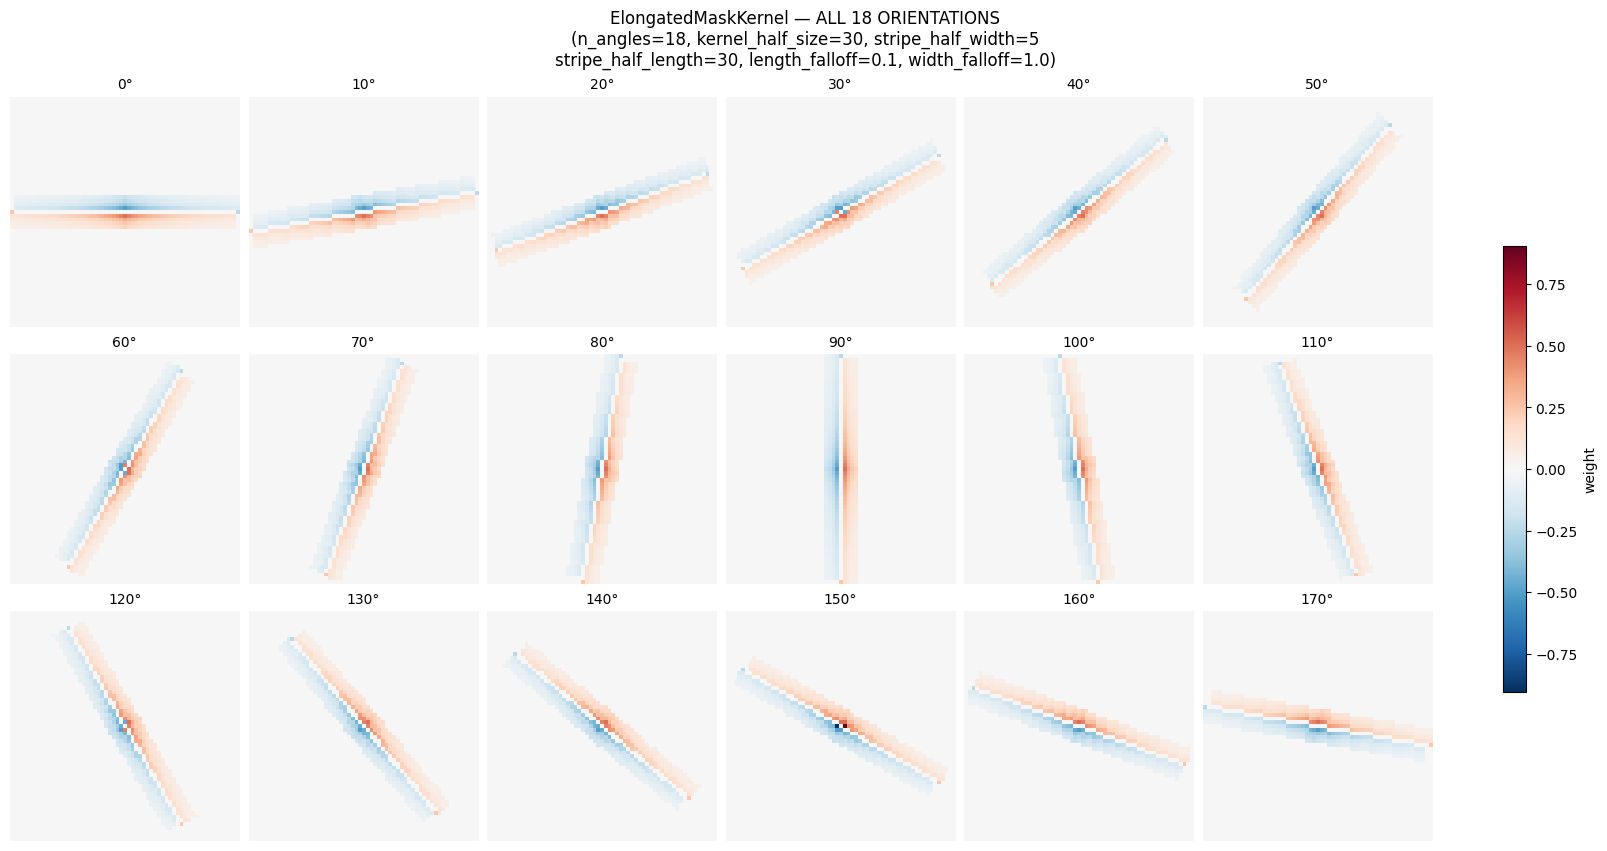

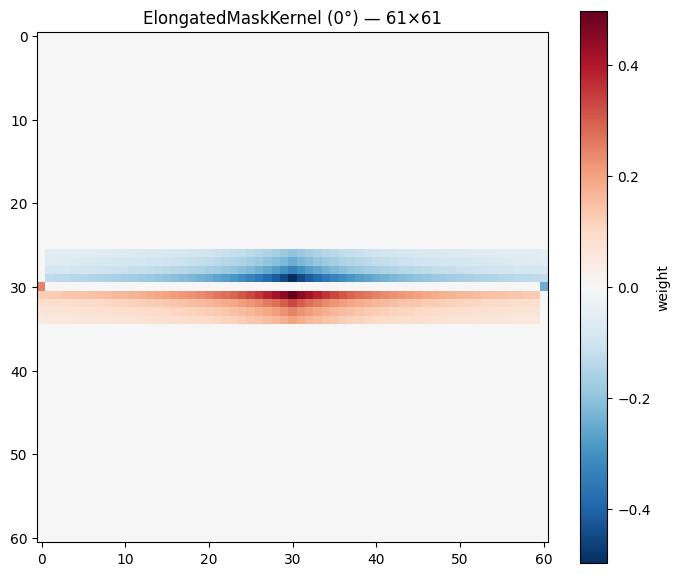

In [4]:
fine_kernel.plot_all(save_path="kernel_grid.png", show=False)
fine_kernel.plot(index=0, save_path="kernel_single.png", show=False)

print("Saved: kernel_grid.png, kernel_single.png")